# Support Vector Machine: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Support Vector Machine** in Python.

### Concept Overview
Finds the margin-maximizing separating boundary hyperplane that creates the widest possible gap between classes.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \ge 1
$$

### Real-World Analogy
**Analogy:** Building a demilitarized zone exactly in the middle between two opposing military camps.

### Worked Example
**Worked Example:** Classifying quality control data. SVM fits decision boundary line. Points sitting right on the margins are the 'Support Vectors'. Any other point can be deleted without shifting the line.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of microchip QC data
from sklearn.datasets import make_classification
np.random.seed(42)
X_raw, y_raw = make_classification(n_samples=400, n_features=2, n_informative=2,
                                  n_redundant=0, n_classes=2, n_clusters_per_class=1,
                                  weights=[0.5, 0.5], class_sep=1.3, random_state=42)
df = pd.DataFrame({
    'Test1': np.round(X_raw[:, 0] * 2.5 + 5.0, 2),
    'Test2': np.round(X_raw[:, 1] * 2.5 + 5.0, 2),
    'Passed': y_raw
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (400, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Test1   400 non-null    float64
 1   Test2   400 non-null    float64
 2   Passed  400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB
            Test1       Test2      Passed
count  400.000000  400.000000  400.000000
mean     8.182225    5.037425    0.500000
std      1.700080    4.110967    0.500626
min      1.190000   -4.640000    0.000000
25%      7.067500    1.780000    0.000000
50%      8.170000    5.270000    0.500000
75%      9.252500    8.255000    1.000000
max     12.980000   14.120000    1.000000


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 Test1     0
Test2     0
Passed    0
dtype: int64
Duplicate count: 1


## 6. Exploratory Data Analysis (EDA)

We perform visual analysis of the dataset, examining correlation heatmaps and target-colored feature distributions to understand the underlying boundaries.

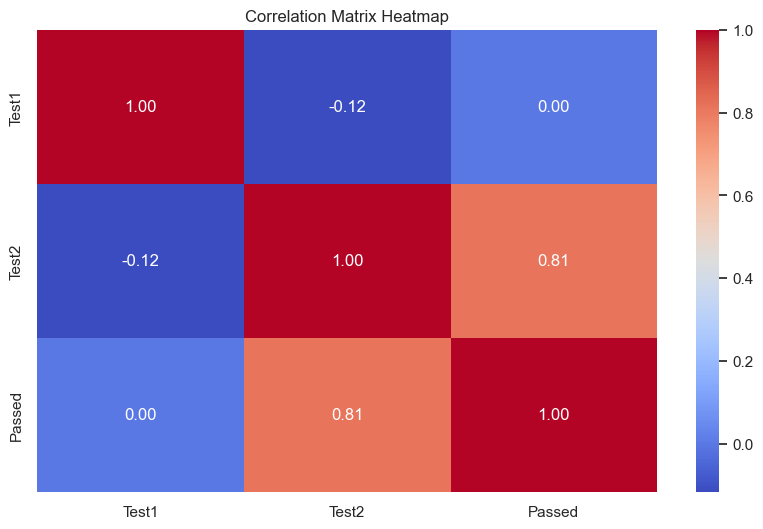

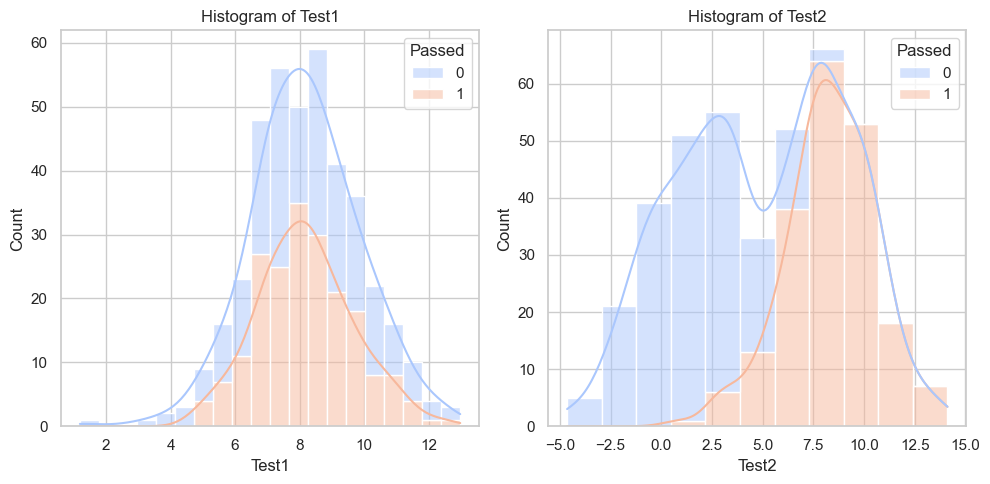

G:\Temp\ipykernel_3120\1348028533.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[1], palette='Set2')


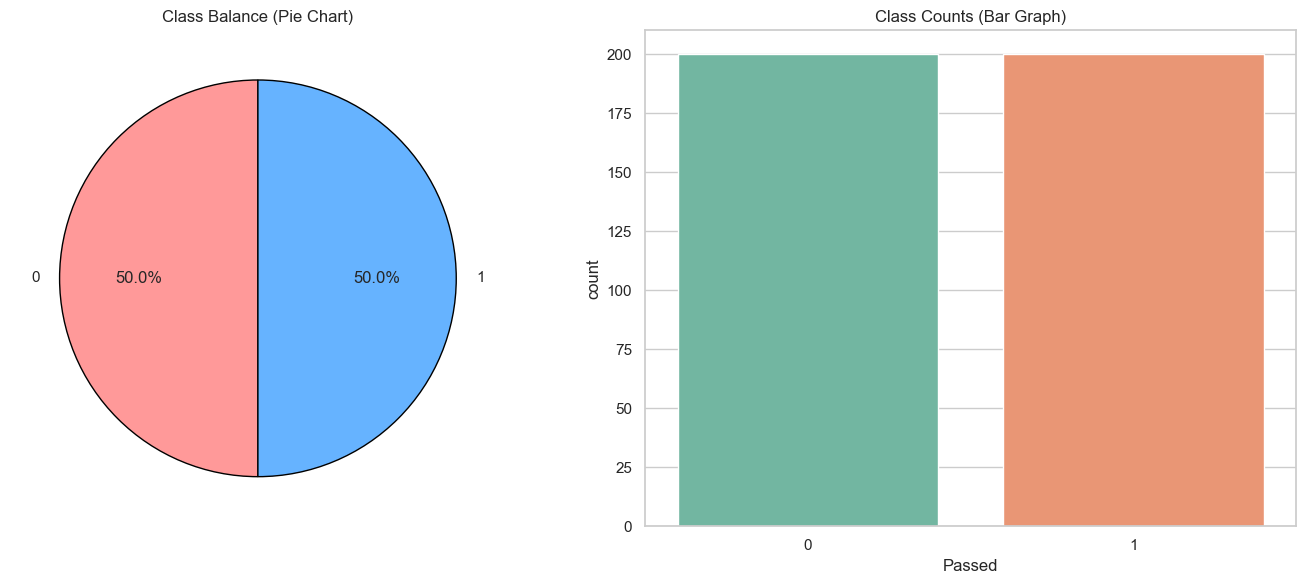

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# 1. Feature Histograms (Continuous distributions colored by class)
X_cols = df.columns[:-1]
target_col = df.columns[-1]
fig, axes = plt.subplots(1, len(X_cols), figsize=(5 * len(X_cols), 5))
if len(X_cols) == 1:
    sns.histplot(data=df, x=X_cols[0], hue=target_col, kde=True, ax=axes, multiple='stack', palette='coolwarm')
    axes.set_title(f'Histogram of {X_cols[0]}')
else:
    for idx, col in enumerate(X_cols):
        sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[idx], multiple='stack', palette='coolwarm')
        axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

# 2. Class Balance Pie Chart and Bar Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Pie chart
class_counts = df[target_col].value_counts()
axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff', '#99ff99'], startangle=90, wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Class Balance (Pie Chart)')
# Bar chart
sns.countplot(data=df, x=target_col, ax=axes[1], palette='Set2')
axes[1].set_title('Class Counts (Bar Graph)')
plt.tight_layout()
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling applied successfully.')

Scaling applied successfully.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (280, 2), Test size: (120, 2)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(X_train, y_train)
print("SVM classification model fit completed.")

SVM classification model fit completed.


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.9333333333333333
Precision: 0.8709677419354839
Recall: 1.0


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

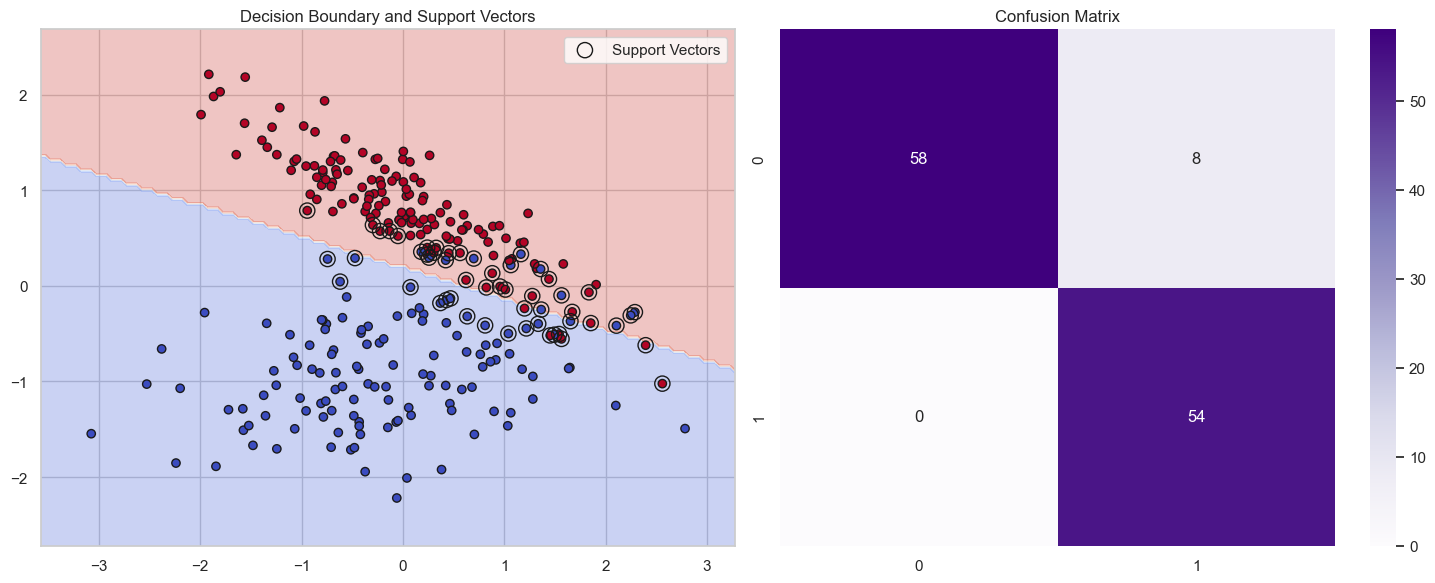

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Decision boundary
h = 0.05
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
# Plot support vectors
sv = model.support_vectors_
axes[0].scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='k', label='Support Vectors')
axes[0].set_title("Decision Boundary and Support Vectors")
axes[0].legend()

# Plot 2: Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What is the kernel trick?**

*A: Mapping non-linearly separable inputs into higher-dimensional coordinate systems using dot-product functions (RBF, Polynomial) without explicitly calculating high-dimensional coordinates.*

**Q2: What is the difference between Hard and Soft Margin SVM?**

*A: Hard margin requires perfect linearly separable data (no errors allowed). Soft margin uses a slack variable C to allow some training errors to find a wider margin that generalizes better.*

**Q3: How does parameter C regulate regularization?**

*A: A large C penalizes misclassifications heavily, leading to a narrower margin (risk of overfitting). A small C allows errors, creating a wider margin (risk of underfitting).*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What are support vectors?**

*A: The key data points sitting right on the margins that determine the boundary hyperplane.*

**Q2: What is the default kernel in scikit-learn's SVC?**

*A: `rbf` (Radial Basis Function).*

**Q3: Why is scaling important for SVM?**

*A: SVM uses geometric distances to maximize margins. Unscaled variables distort the distance computation.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.